# Thesis Analysis and Diagrams

This notebook is organized into two major sections:

- Section A: Experiment Evaluation
- Section B: Thesis Diagrams

Current main serving pipeline:
**Hybrid RRF -> Answerability Gate -> Focused Context -> Local LLM Answer + Citations**

## SECTION A - EXPERIMENT EVALUATION

In [1]:
import json
from pathlib import Path
import statistics
import shutil

import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Markdown, display, Image

pd.set_option("display.max_colwidth", 220)
pd.set_option("display.width", 180)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

print("Imports ready.")

Imports ready.


In [2]:
def detect_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").exists():
            return p
    return start

PROJECT_ROOT = detect_project_root(Path.cwd())

RETRIEVAL_ABLATION_PATH = PROJECT_ROOT / "data/reports/retrieval_ablation_qset_100_seed42.json"
H1_REPORT_PATH = PROJECT_ROOT / "data/reports/h1_full_report.json"
RETRIEVAL_DEBUG_DIR = PROJECT_ROOT / "data/reports/retrieval_debug"
TABLE_OUTPUT_DIR = PROJECT_ROOT / "data/reports/tables"
FIGURE_OUTPUT_DIR = PROJECT_ROOT / "data/reports/figures"

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"Retrieval ablation: {RETRIEVAL_ABLATION_PATH}")
print(f"H1 report: {H1_REPORT_PATH}")
print(f"Debug dir: {RETRIEVAL_DEBUG_DIR}")
print(f"Table dir: {TABLE_OUTPUT_DIR}")
print(f"Figure dir: {FIGURE_OUTPUT_DIR}")

PROJECT_ROOT: /home/chplay2020/src/vn-yhct-rag/rag-yhct
Retrieval ablation: /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/retrieval_ablation_qset_100_seed42.json
H1 report: /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/h1_full_report.json
Debug dir: /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/retrieval_debug
Table dir: /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/tables
Figure dir: /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/figures


In [3]:
def read_json_safe(path: Path, warnings: list[str], label: str = ""):
    if not path.exists():
        warnings.append(f"WARNING: Missing file: {path}")
        return None
    try:
        with path.open("r", encoding="utf-8") as f:
            return json.load(f)
    except Exception as exc:
        prefix = f"[{label}] " if label else ""
        warnings.append(f"WARNING: {prefix}Failed to parse JSON: {path} ({exc})")
        return None


def list_files_safe(folder: Path, pattern: str, warnings: list[str]) -> list[Path]:
    if not folder.exists():
        warnings.append(f"WARNING: Missing folder: {folder}")
        return []
    return sorted(folder.glob(pattern))


def nested_get(obj, *keys, default=None):
    cur = obj
    for key in keys:
        if isinstance(cur, dict) and key in cur:
            cur = cur[key]
        else:
            return default
    return cur


def first_non_none(*vals):
    for v in vals:
        if v is not None:
            return v
    return None

In [4]:
load_warnings = []

retrieval_ablation = read_json_safe(RETRIEVAL_ABLATION_PATH, load_warnings, "retrieval_ablation")
h1_report = read_json_safe(H1_REPORT_PATH, load_warnings, "h1_report")

debug_all_files = list_files_safe(RETRIEVAL_DEBUG_DIR, "*.json", load_warnings)
debug_gate_files = list_files_safe(RETRIEVAL_DEBUG_DIR, "*_gate.json", load_warnings)
debug_answer_files = list_files_safe(RETRIEVAL_DEBUG_DIR, "*_answer.json", load_warnings)

print("Load status:")
print(f"- retrieval_ablation loaded: {retrieval_ablation is not None}")
print(f"- h1_report loaded: {h1_report is not None}")
print(f"- retrieval_debug files: {len(debug_all_files)}")
print(f"- gate files: {len(debug_gate_files)}")
print(f"- answer files: {len(debug_answer_files)}")

if load_warnings:
    print("\nWarnings:")
    for w in load_warnings:
        print(w)
else:
    print("\nNo loading warnings.")

Load status:
- retrieval_ablation loaded: True
- h1_report loaded: True
- retrieval_debug files: 35
- gate files: 14
- answer files: 5

No loading warnings.


In [5]:
metric_order = ["hit@1", "hit@3", "hit@5", "hit@10", "mrr"]
entity_order = ["chunk_id", "parent_id", "source_id"]


def normalize_metric_key(k: str) -> str:
    return str(k).strip().lower().replace(" ", "")


def get_metric_block(mode_metrics: dict, metric_name: str):
    wanted = normalize_metric_key(metric_name)
    if not isinstance(mode_metrics, dict):
        return {}
    for k, v in mode_metrics.items():
        if normalize_metric_key(k) == wanted and isinstance(v, dict):
            return v
    return {}


rows = []
metrics_block = nested_get(retrieval_ablation or {}, "metrics", default={})

if isinstance(metrics_block, dict) and metrics_block:
    for mode, mode_metrics in metrics_block.items():
        row = {"mode": mode}
        for metric_name in metric_order:
            metric_block = get_metric_block(mode_metrics, metric_name)
            for entity in entity_order:
                row[f"{metric_name}_{entity}"] = metric_block.get(entity) if isinstance(metric_block, dict) else None
        rows.append(row)
else:
    print("WARNING: retrieval ablation metrics missing or empty.")

df_retrieval_summary = pd.DataFrame(rows)
if not df_retrieval_summary.empty:
    numeric_cols = [c for c in df_retrieval_summary.columns if c != "mode"]
    df_retrieval_summary[numeric_cols] = df_retrieval_summary[numeric_cols].apply(pd.to_numeric, errors="coerce")

    display(Markdown("### Retrieval Summary Table"))
    display(df_retrieval_summary.sort_values("mode").reset_index(drop=True))
else:
    display(Markdown("**Retrieval summary is empty.**"))

### Retrieval Summary Table

,mode,hit@1_chunk_id,hit@1_parent_id,hit@1_source_id,hit@3_chunk_id,hit@3_parent_id,hit@3_source_id,hit@5_chunk_id,hit@5_parent_id,hit@5_source_id,hit@10_chunk_id,hit@10_parent_id,hit@10_source_id,mrr_chunk_id,mrr_parent_id,mrr_source_id
0,bm25,0.36,0.39,0.46,0.57,0.60,0.73,0.59,0.64,0.77,0.67,0.71,0.82,0.4706,0.5063,0.6010
1,hybrid_rrf,0.41,0.49,0.52,0.53,0.62,0.80,0.59,0.65,0.90,0.70,0.77,0.94,0.4958,0.5739,0.6827
2,vector,0.31,0.37,0.55,0.44,0.52,0.82,0.54,0.61,0.87,0.58,0.66,0.90,0.3965,0.4652,0.6919


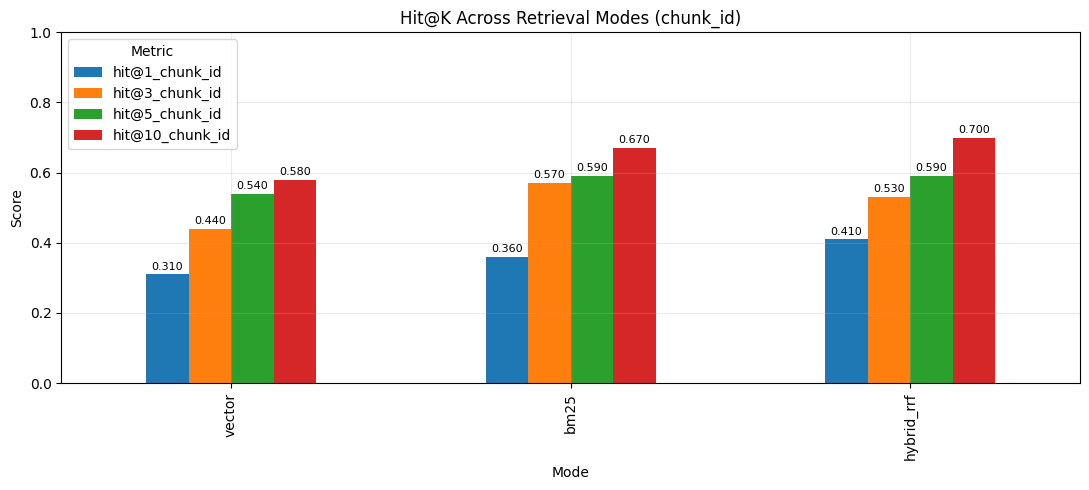

In [6]:
if df_retrieval_summary.empty:
    print("Skip Hit@K chart: retrieval summary is empty.")
else:
    hit_cols = ["hit@1_chunk_id", "hit@3_chunk_id", "hit@5_chunk_id", "hit@10_chunk_id"]
    hit_cols = [c for c in hit_cols if c in df_retrieval_summary.columns]

    if not hit_cols:
        print("No Hit@K chunk_id columns found.")
    else:
        plot_df = df_retrieval_summary[["mode", *hit_cols]].set_index("mode")
        ax = plot_df.plot(kind="bar", figsize=(11, 5))
        ax.set_title("Hit@K Across Retrieval Modes (chunk_id)")
        ax.set_xlabel("Mode")
        ax.set_ylabel("Score")
        ax.set_ylim(0, max(1.0, float(plot_df.max().max()) * 1.2))
        ax.legend(title="Metric")
        for container in ax.containers:
            ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)
        plt.tight_layout()
        plt.show()

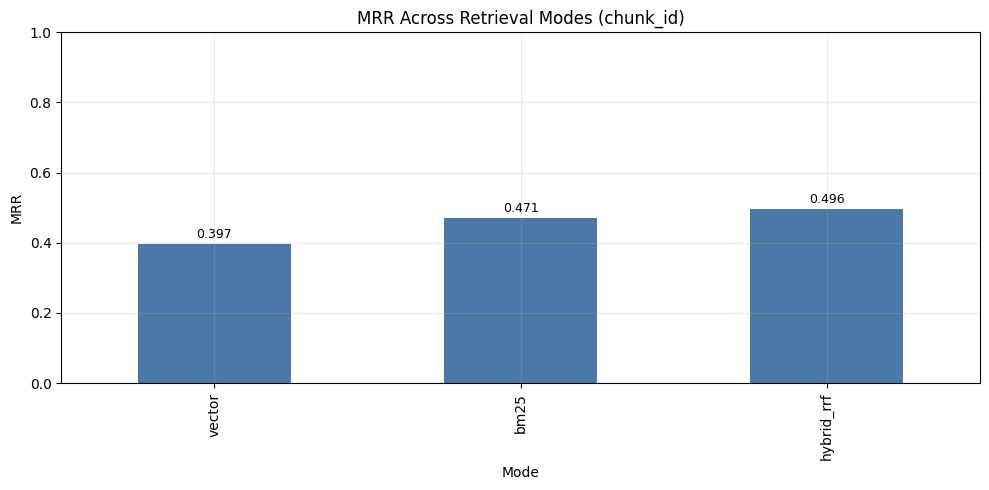

In [7]:
if df_retrieval_summary.empty or "mrr_chunk_id" not in df_retrieval_summary.columns:
    print("Skip MRR chart: mrr_chunk_id not available.")
else:
    mrr_df = df_retrieval_summary[["mode", "mrr_chunk_id"]].dropna()
    ax = mrr_df.plot(kind="bar", x="mode", y="mrr_chunk_id", legend=False, color="#4c78a8")
    ax.set_title("MRR Across Retrieval Modes (chunk_id)")
    ax.set_xlabel("Mode")
    ax.set_ylabel("MRR")
    ax.set_ylim(0, max(1.0, float(mrr_df["mrr_chunk_id"].max()) * 1.25 if not mrr_df.empty else 1.0))
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", fontsize=9, padding=2)
    plt.tight_layout()
    plt.show()

### Hit@10 vs MRR (Vector Only, BM25 Only, Hybrid RRF)

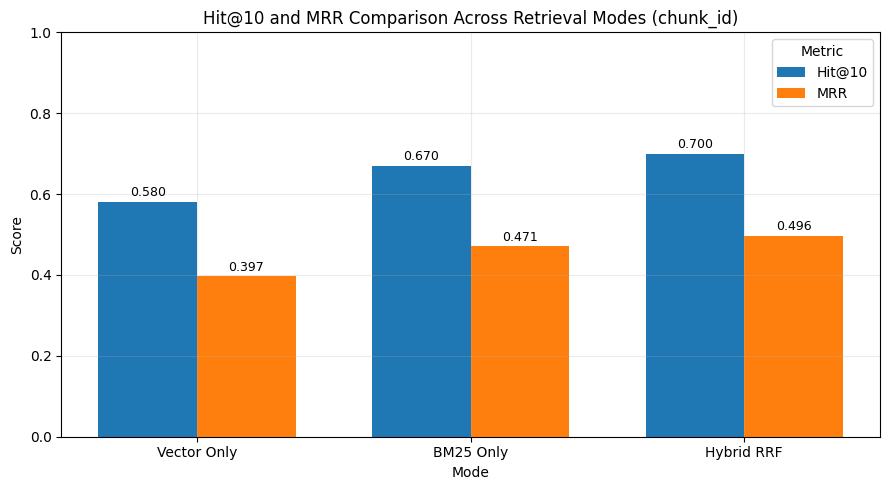

,mode_label,hit@10_chunk_id,mrr_chunk_id
0,Vector Only,0.58,0.3965
1,BM25 Only,0.67,0.4706
2,Hybrid RRF,0.70,0.4958


### Retrieval Results at parent_id and source_id

#### parent_id

,mode,hit@1_parent_id,hit@3_parent_id,hit@5_parent_id,hit@10_parent_id,mrr_parent_id
0,bm25,0.39,0.60,0.64,0.71,0.5063
1,hybrid_rrf,0.49,0.62,0.65,0.77,0.5739
2,vector,0.37,0.52,0.61,0.66,0.4652


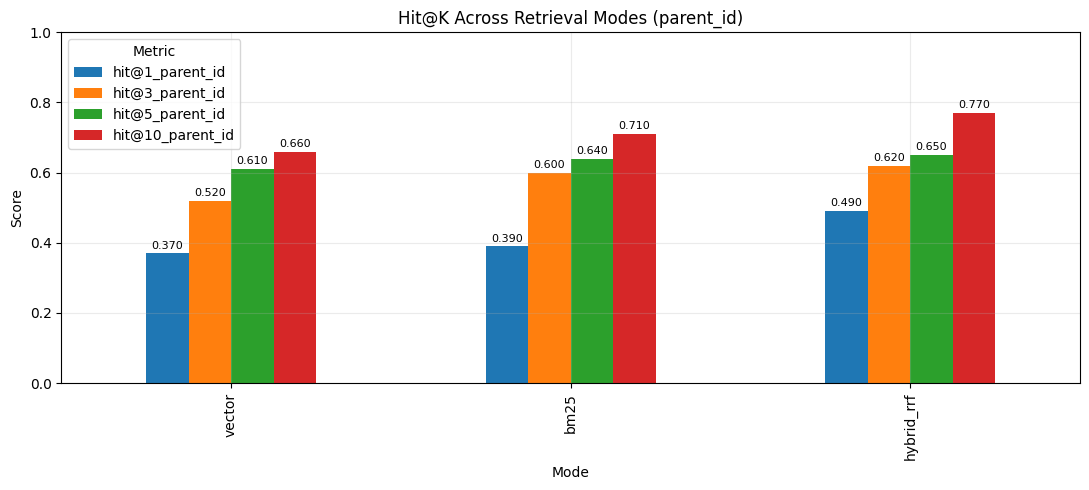

#### source_id

,mode,hit@1_source_id,hit@3_source_id,hit@5_source_id,hit@10_source_id,mrr_source_id
0,bm25,0.46,0.73,0.77,0.82,0.6010
1,hybrid_rrf,0.52,0.80,0.90,0.94,0.6827
2,vector,0.55,0.82,0.87,0.90,0.6919


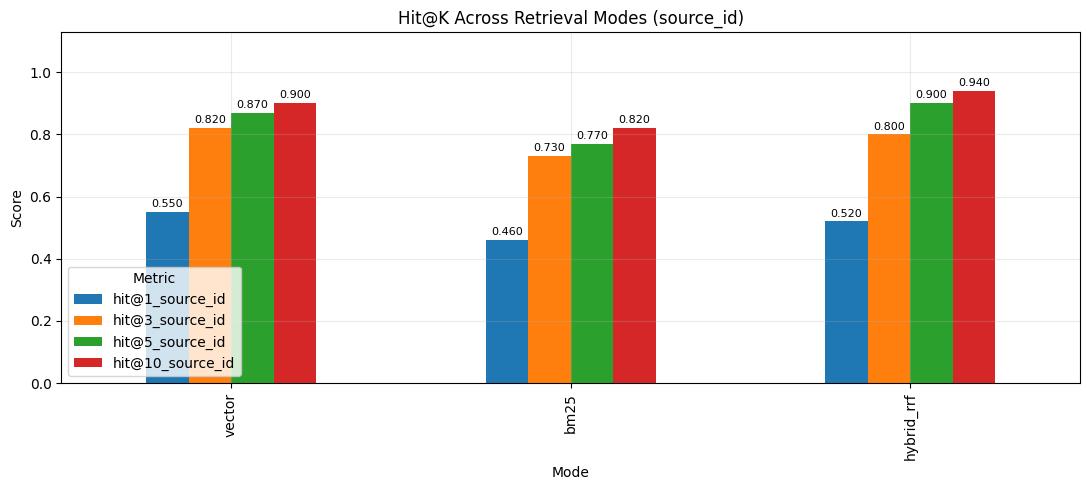

In [8]:
if df_retrieval_summary.empty:
    print("Skip additional retrieval analysis: retrieval summary is empty.")
else:
    # ===== 1) Compare Hit@10 and MRR for Vector / BM25 / Hybrid RRF (chunk_id) =====
    def normalize_mode_name(name: str) -> str:
        return "".join(ch for ch in str(name).lower() if ch.isalnum())

    mode_aliases = [
        (["vector", "vector_only", "dense", "vectoronly"], "Vector Only"),
        (["bm25", "bm25only", "bm25_only", "lexical"], "BM25 Only"),
        (["hybridrrf", "hybrid_rrf", "hybrid", "rrf"], "Hybrid RRF"),
    ]

    available_modes = df_retrieval_summary["mode"].astype(str).tolist()
    mode_lookup = {normalize_mode_name(m): m for m in available_modes}

    selected_rows = []
    for alias_keys, display_name in mode_aliases:
        actual_mode = None
        for alias in alias_keys:
            actual_mode = mode_lookup.get(normalize_mode_name(alias))
            if actual_mode is not None:
                break
        if actual_mode is None:
            continue
        row = df_retrieval_summary.loc[df_retrieval_summary["mode"] == actual_mode].iloc[0].to_dict()
        row["mode_label"] = display_name
        selected_rows.append(row)

    df_compare = pd.DataFrame(selected_rows)
    required_cols = ["hit@10_chunk_id", "mrr_chunk_id"]

    display(Markdown("### Hit@10 vs MRR (Vector Only, BM25 Only, Hybrid RRF)"))
    if df_compare.empty or any(c not in df_compare.columns for c in required_cols):
        print("Comparison chart unavailable: required modes or metrics are missing.")
        print(f"Available modes: {available_modes}")
    else:
        plot_df = df_compare[["mode_label", *required_cols]].copy()
        plot_df[required_cols] = plot_df[required_cols].apply(pd.to_numeric, errors="coerce")
        plot_df = plot_df.dropna(subset=required_cols, how="all")

        if plot_df.empty:
            print("Comparison chart unavailable: no numeric values for Hit@10/MRR.")
        else:
            long_df = plot_df.melt(
                id_vars=["mode_label"],
                value_vars=required_cols,
                var_name="metric",
                value_name="score",
            )
            metric_label_map = {
                "hit@10_chunk_id": "Hit@10",
                "mrr_chunk_id": "MRR",
            }
            long_df["metric"] = long_df["metric"].map(metric_label_map).fillna(long_df["metric"])

            mode_order = [m for m in ["Vector Only", "BM25 Only", "Hybrid RRF"] if m in set(long_df["mode_label"])]
            metric_order_local = ["Hit@10", "MRR"]
            x = range(len(mode_order))
            width = 0.36

            fig, ax = plt.subplots(figsize=(9, 5))
            for i, metric_name in enumerate(metric_order_local):
                vals = []
                for mode_name in mode_order:
                    m = long_df[(long_df["mode_label"] == mode_name) & (long_df["metric"] == metric_name)]
                    vals.append(float(m["score"].iloc[0]) if not m.empty and pd.notna(m["score"].iloc[0]) else 0.0)
                bars = ax.bar([p + (i - 0.5) * width for p in x], vals, width=width, label=metric_name)
                ax.bar_label(bars, fmt="%.3f", fontsize=9, padding=2)

            ax.set_title("Hit@10 and MRR Comparison Across Retrieval Modes (chunk_id)")
            ax.set_xlabel("Mode")
            ax.set_ylabel("Score")
            ax.set_xticks(list(x))
            ax.set_xticklabels(mode_order)
            ax.set_ylim(0, max(1.0, float(long_df["score"].max()) * 1.25 if not long_df.empty else 1.0))
            ax.legend(title="Metric")
            plt.tight_layout()
            plt.show()

            display(plot_df.reset_index(drop=True))

    # ===== 2) Retrieval results at parent_id and source_id =====
    display(Markdown("### Retrieval Results at parent_id and source_id"))

    parent_cols = [
        "hit@1_parent_id",
        "hit@3_parent_id",
        "hit@5_parent_id",
        "hit@10_parent_id",
        "mrr_parent_id",
    ]
    source_cols = [
        "hit@1_source_id",
        "hit@3_source_id",
        "hit@5_source_id",
        "hit@10_source_id",
        "mrr_source_id",
    ]

    available_parent_cols = [c for c in parent_cols if c in df_retrieval_summary.columns]
    available_source_cols = [c for c in source_cols if c in df_retrieval_summary.columns]

    # Reusable Hit@K chart for a given entity level (same style as chunk_id chart).
    def plot_hitk_by_level(df_level: pd.DataFrame, level_name: str) -> None:
        hit_cols = [f"hit@1_{level_name}", f"hit@3_{level_name}", f"hit@5_{level_name}", f"hit@10_{level_name}"]
        hit_cols = [c for c in hit_cols if c in df_level.columns]
        if not hit_cols:
            print(f"No Hit@K columns found for {level_name}.")
            return
        plot_df_level = df_level[["mode", *hit_cols]].copy().set_index("mode")
        ax = plot_df_level.plot(kind="bar", figsize=(11, 5))
        ax.set_title(f"Hit@K Across Retrieval Modes ({level_name})")
        ax.set_xlabel("Mode")
        ax.set_ylabel("Score")
        ax.set_ylim(0, max(1.0, float(plot_df_level.max().max()) * 1.2))
        ax.legend(title="Metric")
        for container in ax.containers:
            ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)
        plt.tight_layout()
        plt.show()

    if available_parent_cols:
        df_parent = df_retrieval_summary[["mode", *available_parent_cols]].copy()
        df_parent[available_parent_cols] = df_parent[available_parent_cols].apply(pd.to_numeric, errors="coerce")
        display(Markdown("#### parent_id"))
        display(df_parent.sort_values("mode").reset_index(drop=True))
        plot_hitk_by_level(df_parent, "parent_id")
    else:
        print("No parent_id retrieval columns found.")

    if available_source_cols:
        df_source = df_retrieval_summary[["mode", *available_source_cols]].copy()
        df_source[available_source_cols] = df_source[available_source_cols].apply(pd.to_numeric, errors="coerce")
        display(Markdown("#### source_id"))
        display(df_source.sort_values("mode").reset_index(drop=True))
        plot_hitk_by_level(df_source, "source_id")
    else:
        print("No source_id retrieval columns found.")

In [9]:
if h1_report is None:
    df_h1_summary = pd.DataFrame(columns=["metric", "value"])
    print("H1 report missing.")
else:
    error_counts = nested_get(h1_report, "error_counts", default={}) or {}
    df_h1_summary = pd.DataFrame({
        "metric": [
            "Raw passages",
            "Clean passages",
            "Chunks",
            "Noise count",
            "Qdrant count",
            "Error chunks",
            "Parent count"
        ],
        "value": [
            nested_get(h1_report, "raw", "count"),
            nested_get(h1_report, "clean", "count"),
            nested_get(h1_report, "chunks", "count"),
            nested_get(h1_report, "chunks", "noise_count"),
            first_non_none(nested_get(h1_report, "qdrant", "point_count"), nested_get(h1_report, "qdrant", "points_count")),
            (error_counts.get("fffd_chunks", 0) + error_counts.get("letter_nl_letter_chunks", 0) + error_counts.get("sci_name_split_chunks", 0)),
            first_non_none(nested_get(h1_report, "parents", "count"), nested_get(h1_report, "chunks", "unique_parent_ids"))
        ]
    })

display(Markdown("### H1 Summary Table"))
display(df_h1_summary)

### H1 Summary Table

,metric,value
0,Raw passages,21029.0
1,Clean passages,21029.0
2,Chunks,24620.0
3,Noise count,59.0
4,Qdrant count,24553.0
5,Error chunks,4.0
6,Parent count,NaN


In [10]:
def stem_without_suffix(path: Path, suffix: str) -> str:
    n = path.name
    return n[:-len(suffix)] if n.endswith(suffix) else path.stem


gate_map = {stem_without_suffix(p, "_gate.json"): p for p in debug_gate_files}
answer_map = {stem_without_suffix(p, "_answer.json"): p for p in debug_answer_files}
base_map = {p.stem: p for p in debug_all_files if not p.name.endswith("_gate.json") and not p.name.endswith("_answer.json")}
all_run_ids = sorted(set(gate_map) | set(answer_map) | set(base_map))

parse_warnings = []
rows = []

for run_id in all_run_ids:
    gate_obj = read_json_safe(gate_map[run_id], parse_warnings, f"gate:{run_id}") if run_id in gate_map else None
    answer_obj = read_json_safe(answer_map[run_id], parse_warnings, f"answer:{run_id}") if run_id in answer_map else None
    base_obj = read_json_safe(base_map[run_id], parse_warnings, f"base:{run_id}") if run_id in base_map else None

    query = first_non_none(
        nested_get(answer_obj or {}, "query"),
        nested_get(gate_obj or {}, "query"),
        nested_get(base_obj or {}, "query")
    )

    gate_pass = first_non_none(
        nested_get(gate_obj or {}, "gate_pass"),
        nested_get(answer_obj or {}, "gate_result", "pass")
    )

    gate_reason = first_non_none(
        nested_get(gate_obj or {}, "reason"),
        nested_get(answer_obj or {}, "gate_result", "reason")
    )

    predicted_citation_count = first_non_none(
        nested_get(gate_obj or {}, "predicted_citation_count"),
        nested_get(answer_obj or {}, "gate_result", "predicted_citation_count")
    )

    final_context_token_count = first_non_none(
        nested_get(answer_obj or {}, "context", "debug", "final_context_token_count"),
        nested_get(answer_obj or {}, "context", "debug", "final_context_tokens"),
        nested_get(gate_obj or {}, "context", "debug", "final_context_token_count"),
        nested_get(gate_obj or {}, "context", "debug", "final_context_tokens")
    )

    answer_text = first_non_none(
        nested_get(answer_obj or {}, "answer", "answer"),
        nested_get(answer_obj or {}, "answer")
    )

    answer_generated = bool(isinstance(answer_text, str) and answer_text.strip())
    abstained = bool(gate_pass is False and not answer_generated)

    evidence = nested_get(answer_obj or {}, "answer", "evidence", default=[])
    if not isinstance(evidence, list):
        evidence = []

    evidence_count = first_non_none(
        len(evidence) if evidence else None,
        nested_get(gate_obj or {}, "gate_features", "evidence_count"),
        nested_get(answer_obj or {}, "gate_result", "gate_features", "evidence_count")
    )

    rows.append({
        "run_id": run_id,
        "query": query,
        "gate_pass": gate_pass,
        "predicted_citation_count": predicted_citation_count,
        "gate_reason": gate_reason,
        "final_context_token_count": final_context_token_count,
        "answer_generated": answer_generated,
        "abstained": abstained,
        "answer_length": len(answer_text) if isinstance(answer_text, str) else 0,
        "evidence_count": evidence_count
    })

df_gate_summary = pd.DataFrame(rows)

if not df_gate_summary.empty:
    for col in ["predicted_citation_count", "final_context_token_count", "answer_length", "evidence_count"]:
        if col in df_gate_summary.columns:
            df_gate_summary[col] = pd.to_numeric(df_gate_summary[col], errors="coerce")

display(Markdown("### Gate and Answer Debug Summary"))
if not df_gate_summary.empty:
    display(df_gate_summary)
else:
    print("No gate/answer debug rows available.")

if parse_warnings:
    print("\nParse warnings:")
    for w in parse_warnings:
        print(w)

### Gate and Answer Debug Summary

,run_id,query,gate_pass,predicted_citation_count,gate_reason,final_context_token_count,answer_generated,abstained,answer_length,evidence_count
0,bm25_263aee33,tác dụng của cây ngải cứu,None,NaN,None,NaN,False,False,0,NaN
1,hybrid_rrf_09b8db9d,Cây Mã Đề,True,4.0,Sufficient and agreeing evidence from hybrid retrieval.,NaN,False,False,0,5.0
2,hybrid_rrf_263aee33,tác dụng của cây ngải cứu,True,4.0,Sufficient and agreeing evidence from hybrid retrieval.,1669.0,True,False,538,3.0
3,hybrid_rrf_3fe8052c,cách chữa trẻ em ho do cảm lạnh bằng cây thuốc-dược liệu là gì,False,1.0,Insufficient strong evidence passages.,NaN,False,True,0,1.0
4,hybrid_rrf_4143dfa4,tác dụng của cây sả,True,4.0,Sufficient and agreeing evidence from hybrid retrieval.,3500.0,True,False,269,4.0
5,hybrid_rrf_492bba9f,tác dụng của cây xả,True,4.0,Sufficient and agreeing evidence from hybrid retrieval.,NaN,False,False,0,5.0
6,hybrid_rrf_4a49a95e,"Dược liệu chữa ho, hen là gì",False,1.0,Insufficient strong evidence passages.,NaN,False,True,0,1.0
7,hybrid_rrf_760bd221,cây chi sả có tên khác là gì,True,4.0,Sufficient and agreeing evidence from hybrid retrieval.,NaN,False,False,0,5.0
8,hybrid_rrf_7e7ba53b,Tên khoa học của cây câu kỷ là gì,True,4.0,Sufficient and agreeing evidence from hybrid retrieval.,NaN,False,False,0,5.0
9,hybrid_rrf_82132096,cách chữa trẻ em ho do cảm lạnh là gì,False,2.0,Evidence lacks concentrated agreement (same parent/source).,NaN,False,True,0,2.0


### Gate Statistics

,metric,value
0,total_queries,16.000000
1,gate_pass,9.000000
2,gate_fail,5.000000
3,abstained,4.000000
4,answer_generated,5.000000
5,avg_evidence_count,3.428571
6,avg_context_tokens,2979.400000


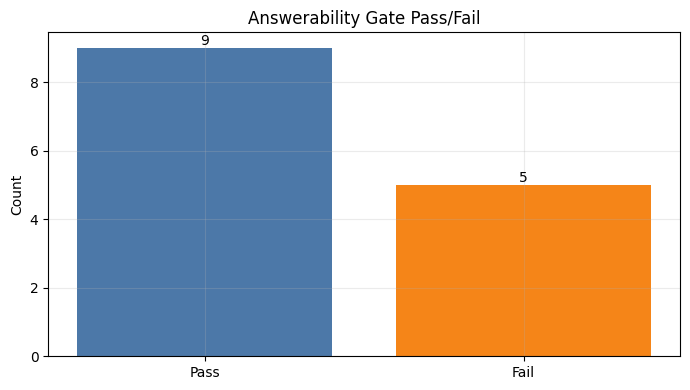

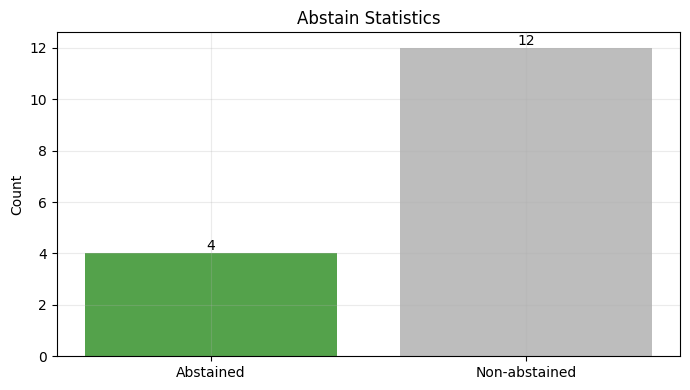

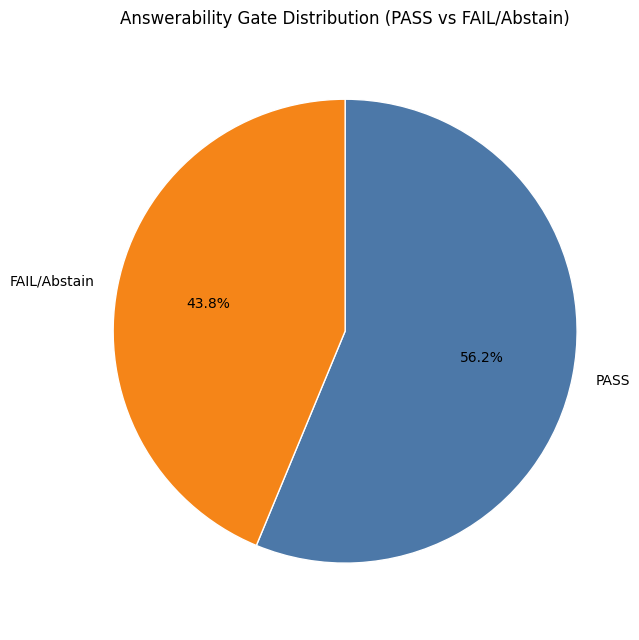

In [11]:
if df_gate_summary.empty:
    df_gate_stats = pd.DataFrame(columns=["metric", "value"])
    print("No gate data available for statistics/charts.")
else:
    n_total = len(df_gate_summary)
    n_pass = int((df_gate_summary["gate_pass"] == True).sum())
    n_fail = int((df_gate_summary["gate_pass"] == False).sum())
    n_abstained = int((df_gate_summary["abstained"] == True).sum())
    n_answered = int((df_gate_summary["answer_generated"] == True).sum())

    evidence_vals = [v for v in df_gate_summary["evidence_count"].dropna().tolist() if pd.notna(v)]
    context_vals = [v for v in df_gate_summary["final_context_token_count"].dropna().tolist() if pd.notna(v)]

    avg_evidence = statistics.fmean(evidence_vals) if evidence_vals else None
    avg_context = statistics.fmean(context_vals) if context_vals else None

    df_gate_stats = pd.DataFrame({
        "metric": [
            "total_queries",
            "gate_pass",
            "gate_fail",
            "abstained",
            "answer_generated",
            "avg_evidence_count",
            "avg_context_tokens"
        ],
        "value": [n_total, n_pass, n_fail, n_abstained, n_answered, avg_evidence, avg_context]
    })

    display(Markdown("### Gate Statistics"))
    display(df_gate_stats)

    fig, ax = plt.subplots(figsize=(7, 4))
    labels = ["Pass", "Fail"]
    vals = [n_pass, n_fail]
    bars = ax.bar(labels, vals, color=["#4c78a8", "#f58518"])
    ax.set_title("Answerability Gate Pass/Fail")
    ax.set_ylabel("Count")
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{int(b.get_height())}", ha="center", va="bottom")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 4))
    labels = ["Abstained", "Non-abstained"]
    vals = [n_abstained, max(0, n_total - n_abstained)]
    bars = ax.bar(labels, vals, color=["#54a24b", "#bdbdbd"])
    ax.set_title("Abstain Statistics")
    ax.set_ylabel("Count")
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{int(b.get_height())}", ha="center", va="bottom")
    plt.tight_layout()
    plt.show()

    # Pie chart requested for thesis: PASS vs FAIL/Abstain distribution.
    n_fail_or_abstain = max(0, n_total - n_pass)
    pie_labels = ["PASS", "FAIL/Abstain"]
    pie_sizes = [n_pass, n_fail_or_abstain]

    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    wedges, texts, autotexts = ax.pie(
        pie_sizes,
        labels=pie_labels,
        colors=["#4c78a8", "#f58518"],
        autopct="%1.1f%%",
        startangle=90,
        counterclock=False,
        wedgeprops={"linewidth": 1.0, "edgecolor": "white"},
    )
    ax.set_title("Answerability Gate Distribution (PASS vs FAIL/Abstain)")
    ax.axis("equal")
    plt.tight_layout()
    plt.show()

In [12]:
TABLE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

exported_tables = []

p1 = TABLE_OUTPUT_DIR / "thesis_retrieval_summary.csv"
df_retrieval_summary.to_csv(p1, index=False)
exported_tables.append(p1)

p2 = TABLE_OUTPUT_DIR / "thesis_h1_summary.csv"
df_h1_summary.to_csv(p2, index=False)
exported_tables.append(p2)

p3 = TABLE_OUTPUT_DIR / "thesis_gate_summary.csv"
df_gate_summary.to_csv(p3, index=False)
exported_tables.append(p3)

p4 = TABLE_OUTPUT_DIR / "thesis_gate_stats.csv"
df_gate_stats.to_csv(p4, index=False)
exported_tables.append(p4)

print("Exported tables:")
for p in exported_tables:
    print(f"- {p}")

Exported tables:
- /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/tables/thesis_retrieval_summary.csv
- /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/tables/thesis_h1_summary.csv
- /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/tables/thesis_gate_summary.csv
- /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/tables/thesis_gate_stats.csv


## SECTION B - THESIS DIAGRAMS

In [13]:
from IPython.display import Image, SVG, display

FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
EXPORTED_FIGURES = []

graphviz = None
GRAPHVIZ_PYTHON_AVAILABLE = False
GRAPHVIZ_DOT_AVAILABLE = False

try:
    import graphviz  # type: ignore
    GRAPHVIZ_PYTHON_AVAILABLE = True
except Exception:
    GRAPHVIZ_PYTHON_AVAILABLE = False

if GRAPHVIZ_PYTHON_AVAILABLE and shutil.which("dot"):
    GRAPHVIZ_DOT_AVAILABLE = True

if not GRAPHVIZ_PYTHON_AVAILABLE:
    print("Warning: Python package 'graphviz' is not available. Install with: pip install graphviz")
elif not GRAPHVIZ_DOT_AVAILABLE:
    print("Warning: Graphviz Python package is installed but system binary 'dot' is missing.")
    print("Install Graphviz binary, then re-run Section B to render diagrams.")
else:
    print("Graphviz is fully available.")

GRAPH_STYLE = {
    "fontname": "Helvetica",
    "fontsize_node": "12",
    "fontsize_edge": "10",
    "color": "#222222",
    "bgcolor": "white",
    "nodesep": "0.5",
    "ranksep": "0.8",
    "pad": "0.3",
    "margin": "0.12,0.08",
}


def _track_export(path_obj: Path) -> None:
    p = str(path_obj)
    if p not in EXPORTED_FIGURES:
        EXPORTED_FIGURES.append(p)


def graphviz_ready(diagram_name: str) -> bool:
    if GRAPHVIZ_PYTHON_AVAILABLE and GRAPHVIZ_DOT_AVAILABLE:
        return True
    print(f"Skipped '{diagram_name}': Graphviz renderer is unavailable.")
    if GRAPHVIZ_PYTHON_AVAILABLE and not GRAPHVIZ_DOT_AVAILABLE:
        print("Hint: install Graphviz binary so 'dot' is on PATH.")
    elif not GRAPHVIZ_PYTHON_AVAILABLE:
        print("Hint: install Python package graphviz and Graphviz binary.")
    return False


def build_base_graph(title: str, rankdir: str = "LR", splines: str = "ortho") -> "graphviz.Digraph":
    dot = graphviz.Digraph(comment=title)
    dot.attr(
        rankdir=rankdir,
        bgcolor=GRAPH_STYLE["bgcolor"],
        labelloc="t",
        label=title,
        nodesep=GRAPH_STYLE["nodesep"],
        ranksep=GRAPH_STYLE["ranksep"],
        pad=GRAPH_STYLE["pad"],
        splines=splines,
    )
    dot.attr(
        "node",
        shape="box",
        style="rounded",
        color=GRAPH_STYLE["color"],
        penwidth="1.6",
        fontname=GRAPH_STYLE["fontname"],
        fontsize=GRAPH_STYLE["fontsize_node"],
        margin=GRAPH_STYLE["margin"],
    )
    dot.attr(
        "edge",
        color=GRAPH_STYLE["color"],
        penwidth="1.4",
        arrowsize="0.7",
        fontname=GRAPH_STYLE["fontname"],
        fontsize=GRAPH_STYLE["fontsize_edge"],
    )
    return dot


def add_process(dot: "graphviz.Digraph", node_id: str, label: str, emphasized: bool = False) -> None:
    if emphasized:
        dot.node(node_id, label, shape="box", style="rounded,filled", fillcolor="#f6f6f6", penwidth="2.0")
    else:
        dot.node(node_id, label, shape="box", style="rounded")


def add_decision(dot: "graphviz.Digraph", node_id: str, label: str) -> None:
    dot.node(node_id, label, shape="diamond", style="", penwidth="1.8")


def add_store(dot: "graphviz.Digraph", node_id: str, label: str) -> None:
    dot.node(node_id, label, shape="cylinder", style="", penwidth="1.8")


def render_graphviz_diagram(name: str, dot: "graphviz.Digraph") -> Path | None:
    if not graphviz_ready(name):
        return None
    try:
        base = FIGURE_OUTPUT_DIR / name
        dot.format = "png"
        png_path = Path(dot.render(str(base), cleanup=True))
        _track_export(png_path)

        dot.format = "svg"
        svg_path = Path(dot.render(str(base), cleanup=True))
        _track_export(svg_path)

        display(Image(filename=str(png_path)))
        return png_path
    except Exception as exc:
        print(f"Graphviz rendering failed for '{name}': {exc}")
        return None


def build_graphviz_system_overview() -> "graphviz.Digraph":
    title = "System Overview Architecture"
    dot = build_base_graph(title=title, rankdir="LR", splines="ortho")

    with dot.subgraph(name="cluster_offline") as c:
        c.attr(label="Offline Indexing", color="#b9b9b9", style="rounded", bgcolor="white", pencolor="#b9b9b9")
        add_process(c, "src", "Document\nSources")
        add_process(c, "ing", "Ingest /\nClean")
        add_process(c, "chunk", "Chunking +\nParent-Child")
        add_store(c, "bm25", "BM25\nIndex")
        add_store(c, "vec", "Vector\nDB")
        c.edge("src", "ing")
        c.edge("ing", "chunk")
        c.edge("chunk", "bm25")
        c.edge("chunk", "vec")
        c.body.append("{ rank=same; bm25; vec; }")

    with dot.subgraph(name="cluster_online") as c:
        c.attr(label="Online Inference", color="#b9b9b9", style="rounded", bgcolor="white", pencolor="#b9b9b9")
        add_process(c, "query", "Query")
        add_process(c, "hy", "Hybrid\nRetrieval")
        add_decision(c, "gate", "Gate")
        add_process(c, "ctx", "Focused\nContext")
        add_process(c, "llm", "Local LLM\nAnswer + Citations", emphasized=True)
        add_process(c, "ui", "Streamlit UI", emphasized=True)
        c.edge("query", "hy")
        c.edge("hy", "gate")
        c.edge("gate", "ctx", xlabel="pass")
        c.edge("ctx", "llm")
        c.edge("llm", "ui")

    dot.edge("hy", "bm25", xlabel="lexical", constraint="false")
    dot.edge("hy", "vec", xlabel="dense", constraint="false")
    return dot


def build_graphviz_offline_pipeline() -> "graphviz.Digraph":
    title = "Offline Indexing Pipeline"
    dot = build_base_graph(title=title, rankdir="LR", splines="ortho")

    add_process(dot, "raw", "Raw\nDocuments")
    add_process(dot, "clean", "Clean\nPassages")
    add_process(dot, "chunks", "Chunks")
    add_store(dot, "bm25", "BM25\nIndex")
    add_process(dot, "emb", "Embeddings")
    add_store(dot, "vdb", "Vector\nDB")
    add_store(dot, "parents", "Parents\nJSONL")

    dot.edge("raw", "clean")
    dot.edge("clean", "chunks")
    dot.edge("chunks", "bm25")
    dot.edge("chunks", "emb")
    dot.edge("emb", "vdb")
    dot.edge("chunks", "parents")
    dot.body.append("{ rank=same; bm25; emb; parents; }")
    dot.body.append("{ rank=same; vdb; }")
    return dot


def build_graphviz_online_pipeline() -> "graphviz.Digraph":
    title = "Online Query-Time Pipeline"
    dot = build_base_graph(title=title, rankdir="TB", splines="ortho")

    add_process(dot, "q", "User\nQuery")
    add_process(dot, "hy", "Hybrid\nRetrieval")
    add_decision(dot, "gate", "Answerability\nGate")
    add_process(dot, "ctx", "Focused\nContext")
    add_process(dot, "ans", "Local LLM\nAnswer + Citations", emphasized=True)
    add_process(dot, "abstain", "Abstain")
    add_process(dot, "out", "Output with\nSafety Note", emphasized=True)

    dot.edge("q", "hy")
    dot.edge("hy", "gate")
    dot.edge("gate", "ctx", xlabel="pass")
    dot.edge("gate", "abstain", xlabel="fail")
    dot.edge("ctx", "ans")
    dot.edge("ans", "out")
    dot.edge("abstain", "out")
    dot.body.append("{ rank=same; ctx; abstain; }")
    return dot


def build_graphviz_experiment_progression() -> "graphviz.Digraph":
    title = "Experiment Progression"
    dot = build_base_graph(title=title, rankdir="LR", splines="polyline")

    add_process(dot, "s1", "Vector-only")
    add_process(dot, "s2", "BM25-only")
    add_process(dot, "s3", "Hybrid RRF")
    add_process(dot, "s4", "Hybrid + Gate")
    add_process(dot, "s5", "Hybrid + Gate\n+ Answer", emphasized=True)

    dot.edge("s1", "s2")
    dot.edge("s2", "s3")
    dot.edge("s3", "s4")
    dot.edge("s4", "s5")
    return dot


def build_graphviz_answer_decision_flow() -> "graphviz.Digraph":
    title = "Answer Decision Flow"
    dot = build_base_graph(title=title, rankdir="TB", splines="ortho")

    add_process(dot, "q", "Query")
    add_process(dot, "ret", "Retrieve")
    add_decision(dot, "gate", "Gate\npass?")
    add_process(dot, "gen", "Generate\ngrounded answer", emphasized=True)
    add_process(dot, "abstain", "Abstain")
    add_process(dot, "out", "Output with\nSafety Note", emphasized=True)

    dot.edge("q", "ret")
    dot.edge("ret", "gate")
    dot.edge("gate", "gen", xlabel="yes")
    dot.edge("gate", "abstain", xlabel="no")
    dot.edge("gen", "out")
    dot.edge("abstain", "out")
    dot.body.append("{ rank=same; gen; abstain; }")
    return dot

Graphviz is fully available.


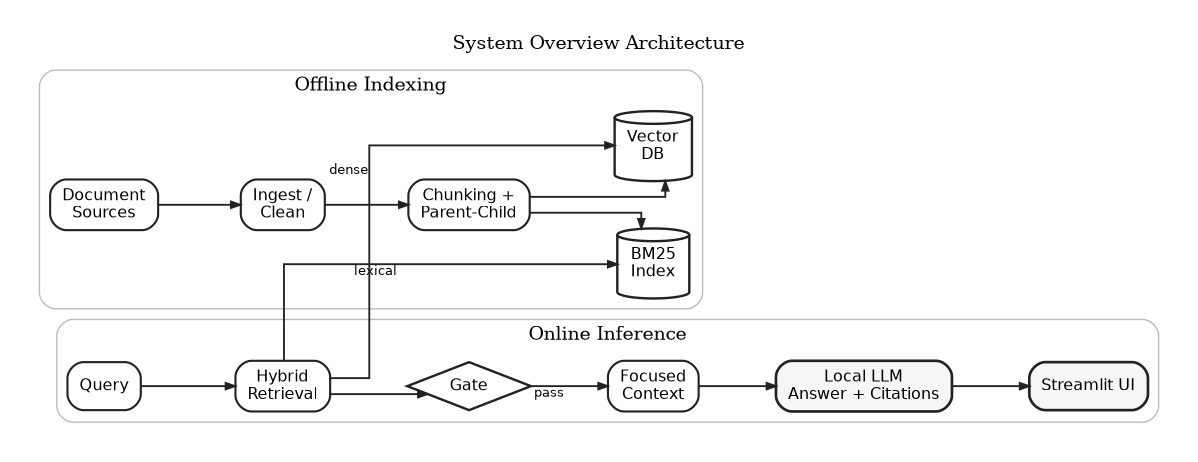

Saved: /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/figures/system_overview.png


In [14]:
# system_overview - Graphviz only
fig_path = None
if graphviz_ready("system_overview"):
    dot = build_graphviz_system_overview()
    fig_path = render_graphviz_diagram("system_overview", dot)
if fig_path is not None:
    print(f"Saved: {fig_path}")

**Figure X.X.** Overview architecture of the proposed RAG system.

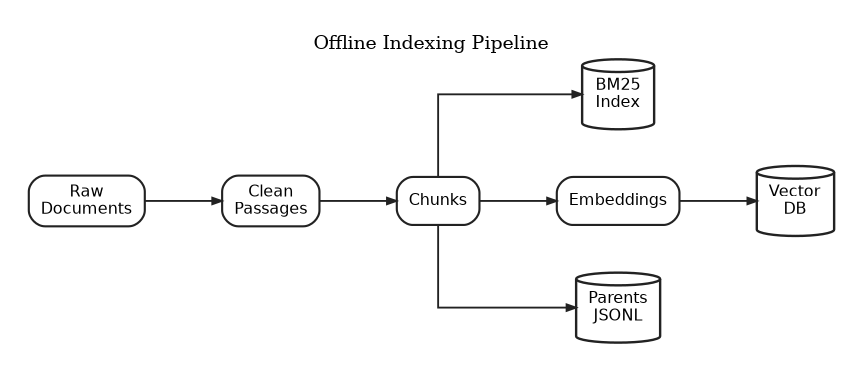

Saved: /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/figures/offline_pipeline.png


In [15]:
# offline_pipeline - Graphviz only
fig_path = None
if graphviz_ready("offline_pipeline"):
    dot = build_graphviz_offline_pipeline()
    fig_path = render_graphviz_diagram("offline_pipeline", dot)
if fig_path is not None:
    print(f"Saved: {fig_path}")

**Figure X.X.** Offline indexing pipeline of the document processing workflow.

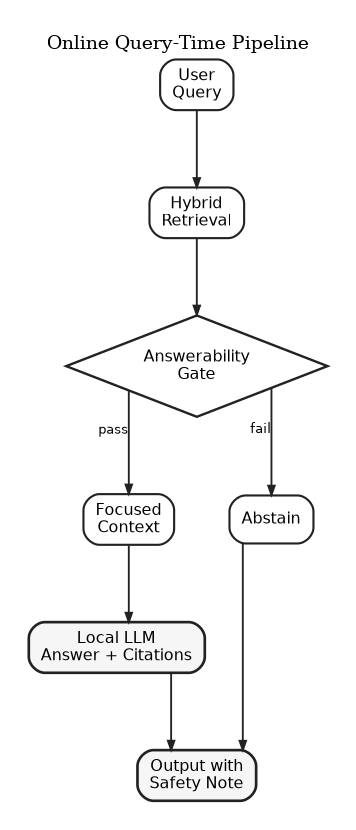

Saved: /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/figures/online_query_pipeline.png


In [16]:
# online_query_pipeline - Graphviz only
fig_path = None
if graphviz_ready("online_query_pipeline"):
    dot = build_graphviz_online_pipeline()
    fig_path = render_graphviz_diagram("online_query_pipeline", dot)
if fig_path is not None:
    print(f"Saved: {fig_path}")

**Figure X.X.** Online query-time pipeline for grounded answer generation.

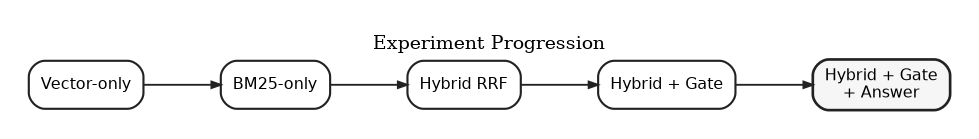

Saved: /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/figures/experiment_progression.png


In [17]:
# experiment_progression - Graphviz only
fig_path = None
if graphviz_ready("experiment_progression"):
    dot = build_graphviz_experiment_progression()
    fig_path = render_graphviz_diagram("experiment_progression", dot)
if fig_path is not None:
    print(f"Saved: {fig_path}")

**Figure X.X.** Experimental progression of retrieval and answer-generation components.

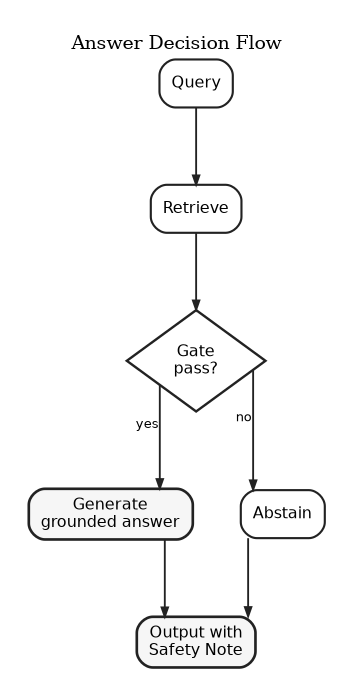

Saved: /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/figures/answer_decision_flow.png


In [18]:
# answer_decision_flow - Graphviz only
fig_path = None
if graphviz_ready("answer_decision_flow"):
    dot = build_graphviz_answer_decision_flow()
    fig_path = render_graphviz_diagram("answer_decision_flow", dot)
if fig_path is not None:
    print(f"Saved: {fig_path}")

**Figure X.X.** Answer decision flow of the proposed RAG system.

In [19]:
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

exported_now = sorted(FIGURE_OUTPUT_DIR.glob("*.png")) + sorted(FIGURE_OUTPUT_DIR.glob("*.svg"))

print("Exported figure files:")
if exported_now:
    for p in exported_now:
        print(f"- {p}")
else:
    print("(No figure files found yet. Run diagram cells above first.)")

Exported figure files:
- /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/figures/answer_decision_flow.png
- /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/figures/experiment_progression.png
- /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/figures/offline_pipeline.png
- /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/figures/online_query_pipeline.png
- /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/figures/system_overview.png
- /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/figures/answer_decision_flow.svg
- /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/figures/experiment_progression.svg
- /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/figures/offline_pipeline.svg
- /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/figures/online_query_pipeline.svg
- /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/figures/system_overview.svg
